# Propensity Score Matching — Olist E-Commerce Installment Payments

Estimates the causal effect of paying via installments (vs. single payment)
on delivery/satisfaction outcomes using Propensity Score Matching.

| | |
|---|---|
| **Treatment** | `treated` — 1 if `payment_installments` > 1, 0 otherwise |
| **Outcome** | `review_score` (and/or `late_delivery` flag) |
| **Dataset** | Olist Brazilian E-Commerce Public Dataset (Kaggle) |

In [381]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import statsmodels.formula.api as smf
from sklearn.neighbors import NearestNeighbors
from scipy import stats

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools import add_constant

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

In [382]:
raw = Path("../data/raw")

orders = pd.read_csv(raw / "olist_orders_dataset.csv", parse_dates=[
    "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date"
])
items       = pd.read_csv(raw / "olist_order_items_dataset.csv")
payments    = pd.read_csv(raw / "olist_order_payments_dataset.csv")
reviews     = pd.read_csv(raw / "olist_order_reviews_dataset.csv")
products    = pd.read_csv(raw / "olist_products_dataset.csv")
customers   = pd.read_csv(raw / "olist_customers_dataset.csv")
sellers     = pd.read_csv(raw / "olist_sellers_dataset.csv")
geolocation = pd.read_csv(raw / "olist_geolocation_dataset.csv")

In [383]:
# one row per order, aggregated item-level info
order_items_agg = (
    items.groupby("order_id")
    .agg(n_items=("order_item_id", "count"),
         item_price=("price", "sum"),
         freight_value=("freight_value", "sum"))
    .reset_index()
)

# one row per order, payment info (installments + total)
payments_agg = (
    payments.groupby("order_id")
    .agg(payment_installments=("payment_installments", "max"),
         payment_value=("payment_value", "sum"),
         payment_type=("payment_type", "first"))
    .reset_index()
)

In [384]:
# category of each order's highest-value item (its "primary" product)
product_category_agg = (
    items.merge(products[["product_id", "product_category_name"]], on="product_id", how="left")
    .sort_values("price", ascending=False)
    .drop_duplicates(subset="order_id", keep="first")
    [["order_id", "product_category_name"]]
    .rename(columns={"product_category_name": "product_category"})
)
product_category_agg["product_category"] = product_category_agg["product_category"].fillna("unknown")

product_category_agg["product_category"].nunique()

74

In [385]:
df = (
    orders
    .merge(order_items_agg, on="order_id", how="inner")
    .merge(payments_agg, on="order_id", how="inner")
    .merge(reviews[["order_id", "review_score"]], on="order_id", how="left")
    .merge(customers[["customer_id", "customer_state"]], on="customer_id", how="left")
    .merge(product_category_agg, on="order_id", how="left")
)

df.shape

(99213, 17)

In [386]:
# bucket categories under 1% of orders into "other" to avoid sparse dummy levels
category_share = df["product_category"].value_counts(normalize=True)
rare_categories = category_share[category_share < 0.01].index
df["product_category"] = df["product_category"].where(~df["product_category"].isin(rare_categories), "other")

df["product_category"].value_counts(normalize=True)

product_category
other                          0.104432
cama_mesa_banho                0.095209
beleza_saude                   0.089252
esporte_lazer                  0.077953
informatica_acessorios         0.067763
moveis_decoracao               0.064356
utilidades_domesticas          0.058893
relogios_presentes             0.056605
telefonia                      0.042172
automotivo                     0.039299
brinquedos                     0.039078
cool_stuff                     0.036417
ferramentas_jardim             0.035066
perfumaria                     0.031841
bebes                          0.028666
eletronicos                    0.025561
papelaria                      0.023172
fashion_bolsas_e_acessorios    0.018828
pet_shop                       0.017185
unknown                        0.014373
moveis_escritorio              0.012851
consoles_games                 0.010664
malas_acessorios               0.010362
Name: proportion, dtype: float64

In [387]:
df['days_to_approved'] = (df['order_approved_at'] - df['order_purchase_timestamp']).dt.days
df['days_to_carrier'] = (df['order_delivered_carrier_date'] - df['order_purchase_timestamp']).dt.days
df['days_to_customer'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
df['days_to_estimated'] = (df['order_estimated_delivery_date'] - df['order_purchase_timestamp']).dt.days

df[['days_to_approved', 'days_to_carrier', 'days_to_customer', 'days_to_estimated']].describe()

,days_to_approved,days_to_carrier,days_to_customer,days_to_estimated
count,99199.000000,98197.000000,97004.000000,99213.000000
mean,0.266132,2.744320,12.099584,23.417738
std,0.774332,3.618002,9.547060,8.828405
min,0.000000,-172.000000,0.000000,2.000000
25%,0.000000,1.000000,6.000000,18.000000
50%,0.000000,2.000000,10.000000,23.000000
75%,0.000000,4.000000,15.000000,28.000000
max,60.000000,125.000000,209.000000,155.000000


In [388]:
df['order_value'] = df['item_price'] + df['freight_value']
df['pct_of_price'] = df['freight_value'] / df['order_value']

df[['order_value', 'pct_of_price']].describe()

,order_value,pct_of_price
count,99213.000000,99213.000000
mean,160.419792,0.208910
std,220.101320,0.125743
min,9.590000,0.000000
25%,61.880000,0.116608
50%,105.280000,0.183256
75%,176.760000,0.275660
max,13664.080000,0.955451


# Data integrated — ready for feature construction / EDA (next notebook step)

In [389]:
df['has_payment_installments'] =  np.where(df['payment_installments'] > 1, 1, 0)
df['has_payment_installments'].value_counts()

has_payment_installments
1    51148
0    48065
Name: count, dtype: int64

In [390]:
# filter to only delivered studies
df_filtered = df[
    (df['order_status'] == 'delivered') & # only delivered
    (df['payment_installments'] > 0) & # 0 payments is bad data
    (df['days_to_carrier'] >= 0) & 
    (df['review_score'].notna()) 
]

In [391]:
df_filtered = df_filtered.drop_duplicates(subset='order_id', keep='last')

In [392]:
df_filtered.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'n_items', 'item_price', 'freight_value', 'payment_installments',
       'payment_value', 'payment_type', 'review_score', 'customer_state',
       'product_category', 'days_to_approved', 'days_to_carrier',
       'days_to_customer', 'days_to_estimated', 'order_value', 'pct_of_price',
       'has_payment_installments'],
      dtype='str')

Dropped 0 rows with missing covariate values for VIF/correlation check


/Users/stringer/.venvs/data/lib/python3.14/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,vif
covariate,
item_price,inf
freight_value,inf
order_value,inf
payment_value,3.633471e+04
n_items,1.238831e+00
payment_installments,1.122721e+00


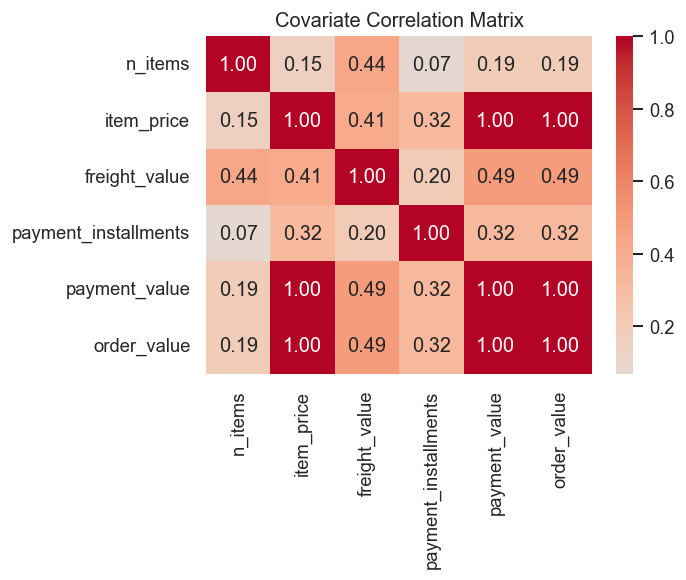

In [393]:
CONTINUOUS = ['n_items', 'item_price', 'freight_value', 'payment_installments', 'payment_value', 'order_value']

vif_data = df_filtered[CONTINUOUS].dropna()
print(f"Dropped {len(df_filtered) - len(vif_data)} rows with missing covariate values for VIF/correlation check")

corr_matrix = vif_data.corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Covariate Correlation Matrix")
plt.tight_layout()

# VIF requires an explicit constant term, otherwise low-variance columns
# (e.g. pct_of_price, which is ~1.0 for almost every order) get spuriously
# inflated VIFs that reflect scale, not collinearity with other covariates.
vif_design = add_constant(vif_data)
vif = pd.DataFrame({
    "covariate": vif_design.columns,
    "vif": [variance_inflation_factor(vif_design.values, i) for i in range(vif_design.shape[1])],
}).set_index("covariate").drop(index="const").sort_values("vif", ascending=False)

vif

In [394]:
TREATMENT = 'has_payment_installments'
OUTCOME = 'review_score'
COVARIATES = ['n_items', 'order_value', 'pct_of_price', 'days_to_carrier', 'days_to_customer', 'days_to_estimated']


print(f"Shape     : {df_filtered.shape}")
print(f"Treated   : {df_filtered[TREATMENT].sum():.0f}")
print(f"Control   : {(1 - df_filtered[TREATMENT]).sum():.0f}")
df_filtered.head()

Shape     : (95663, 24)
Treated   : 49199
Control   : 46464


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,n_items,item_price,...,review_score,customer_state,product_category,days_to_approved,days_to_carrier,days_to_customer,days_to_estimated,order_value,pct_of_price,has_payment_installments
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,29.99,...,4.0,SP,utilidades_domesticas,0.0,2.0,8.0,15,38.71,0.225265,0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,118.70,...,4.0,BA,perfumaria,1.0,1.0,13.0,19,141.46,0.160894,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,159.90,...,5.0,GO,automotivo,0.0,0.0,9.0,26,179.12,0.107302,1
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,45.00,...,5.0,RN,pet_shop,0.0,3.0,13.0,26,72.20,0.376731,0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,19.90,...,5.0,SP,papelaria,0.0,0.0,2.0,12,28.62,0.304682,0


In [395]:
# naive approach do payment installments impact review score
df_filtered.groupby('has_payment_installments')['review_score'].mean()

has_payment_installments
0    4.18905
1    4.12425
Name: review_score, dtype: float64

In [396]:
def smd(df, covariates, treatment):
    """
    Compute standardized mean differences for a list of covariates.

    For each covariate, calculates:
        SMD = (mean_treated - mean_control) / pooled_SD

    where pooled_SD = sqrt((var_treated + var_control) / 2)

    Returns a DataFrame with one row per covariate showing the group means and SMD.
    """
    treated = df[df[treatment] == 1]
    control = df[df[treatment] == 0]
    rows = []

    for col in covariates:
        mt = treated[col].mean()
        mc = control[col].mean()
        pooled_sd = np.sqrt((treated[col].var() + control[col].var()) / 2)
        smd_val = (mt - mc) / pooled_sd if pooled_sd > 0 else np.nan
        rows.append({"covariate": col, "mean_treated": mt, "mean_control": mc, "smd": smd_val})

    return pd.DataFrame(rows).set_index("covariate").sort_values("smd", key=abs, ascending=False)

balance_pre = smd(df_filtered, COVARIATES, TREATMENT)
balance_pre

,mean_treated,mean_control,smd
covariate,,,
pct_of_price,0.183312,0.236149,-0.429594
order_value,197.015945,119.979506,0.361214
days_to_estimated,24.013395,22.691008,0.151481
days_to_carrier,2.606618,2.876420,-0.076212
days_to_customer,12.372944,11.728848,0.068130
n_items,1.156121,1.125560,0.057323


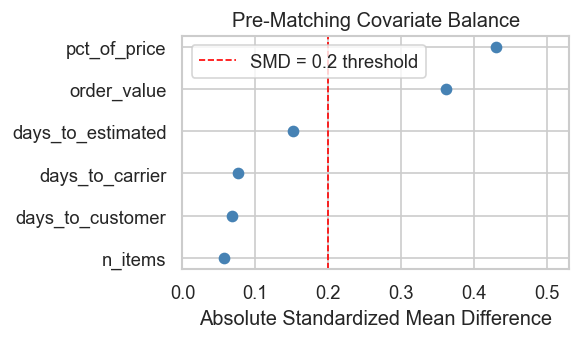

In [397]:
fig, ax = plt.subplots(figsize=(5, len(COVARIATES) * 0.5))

abs_smd = balance_pre["smd"].abs().sort_values()

ax.scatter(abs_smd.values, abs_smd.index, color="steelblue", zorder=3)
ax.axvline(0.2, color="red", linestyle="--", linewidth=1, label="SMD = 0.2 threshold")
ax.set_xlabel("Absolute Standardized Mean Difference")
ax.set_title("Pre-Matching Covariate Balance")
ax.legend()
plt.xlim(0, balance_pre["smd"].abs().max() + 0.1)
plt.tight_layout()
plt.savefig('love_plot.png')

In [398]:
df_filtered.groupby('product_category')['review_score'].mean()

product_category
automotivo                     4.153457
bebes                          4.122121
beleza_saude                   4.232982
brinquedos                     4.241802
cama_mesa_banho                4.007716
consoles_games                 4.180639
cool_stuff                     4.229143
eletronicos                    4.129891
esporte_lazer                  4.235009
fashion_bolsas_e_acessorios    4.243048
ferramentas_jardim             4.201541
informatica_acessorios         4.080977
malas_acessorios               4.372881
moveis_decoracao               4.078793
moveis_escritorio              3.643030
other                          4.185803
papelaria                      4.302921
perfumaria                     4.269042
pet_shop                       4.274087
relogios_presentes             4.121960
telefonia                      4.058111
unknown                        4.037806
utilidades_domesticas          4.205428
Name: review_score, dtype: float64

In [399]:
model_vars = COVARIATES + ["product_category"]
df_model = df_filtered.dropna(subset=model_vars + [TREATMENT]).copy()
print(f"Dropped {len(df_filtered) - len(df_model)} rows with missing model inputs")

formula = f"{TREATMENT} ~ {' + '.join(COVARIATES)} + C(product_category)"
ps_model = smf.logit(formula, data=df_model).fit()
ps_model.summary()

Dropped 7 rows with missing model inputs
Optimization terminated successfully.
         Current function value: 0.642712
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                              Logit Regression Results                              
====================================================================================
Dep. Variable:     has_payment_installments   No. Observations:                95656
Model:                                Logit   Df Residuals:                    95627
Method:                                 MLE   Df Model:                           28
Date:                      Mon, 20 Jul 2026   Pseudo R-squ.:                 0.07222
Time:                              17:53:38   Log-Likelihood:                -61479.
converged:                             True   LL-Null:                       -66265.
Covariance Type:                  nonrobust   LLR p-value:                     0.000
======================================================================================================================
                                                         coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------
Intercept                                             -0.3421      0.043     -8.021      0.000      -0.426      -0.259
C(product_category)[T.bebes]                           0.1846      0.052      3.537      0.000       0.082       0.287
C(product_category)[T.beleza_saude]                    0.3335      0.041      8.167      0.000       0.253       0.414
C(product_category)[T.brinquedos]                      0.1321      0.048      2.764      0.006       0.038       0.226
C(product_category)[T.cama_mesa_banho]                 0.6519      0.041     16.016      0.000       0.572       0.732
C(product_category)[T.consoles_games]                  0.0130      0.075      0.174      0.862      -0.134       0.160
C(product_category)[T.cool_stuff]                      0.3471      0.049      7.038      0.000       0.250       0.444
C(product_category)[T.eletronicos]                    -0.8899      0.063    -14.226      0.000      -1.013      -0.767
C(product_category)[T.esporte_lazer]                  -0.1575      0.042     -3.780      0.000      -0.239      -0.076
C(product_category)[T.fashion_bolsas_e_acessorios]     0.1142      0.059      1.931      0.053      -0.002       0.230
C(product_category)[T.ferramentas_jardim]              0.0492      0.049      1.000      0.317      -0.047       0.146
C(product_category)[T.informatica_acessorios]         -0.4355      0.043    -10.078      0.000      -0.520      -0.351
C(product_category)[T.malas_acessorios]                0.4977      0.074      6.705      0.000       0.352       0.643
C(product_category)[T.moveis_decoracao]                0.2131      0.043      4.944      0.000       0.129       0.298
C(product_category)[T.moveis_escritorio]               0.3699      0.070      5.279      0.000       0.233       0.507
C(product_category)[T.other]                          -0.0635      0.040     -1.585      0.113      -0.142       0.015
C(product_category)[T.papelaria]                       0.1431      0.055      2.595      0.009       0.035       0.251
C(product_category)[T.perfumaria]                      0.5183      0.051     10.117      0.000       0.418       0.619
C(product_category)[T.pet_shop]                        0.1515      0.061      2.497      0.013       0.033       0.271
C(product_category)[T.relogios_presentes]              0.5286      0.045     11.634      0.000       0.440       0.618
C(product_category)[T.telefonia]                       0.0252      0.048      0.526      0.599      -0.069       0.119
C(product_category)[T.unknown]                         0.1294      0.066      1.967      0.049       0.000       0.258
C(product_category)[T.utilidades_domesticas]           0.4270      0.044      9.742      0.000       0.341       0.513
n_items                                                0.0655      0.014      4.543      0.00

In [400]:
df_model["propensity_score"] = ps_model.predict(df_model)
df_model.groupby(TREATMENT)["propensity_score"].describe()

,count,mean,std,min,25%,50%,75%,max
has_payment_installments,,,,,,,,
0,46461.0,0.464331,0.147791,0.031600,0.366174,0.462927,0.562053,1.000000
1,49195.0,0.561474,0.143343,0.007055,0.467863,0.563289,0.656315,0.999994


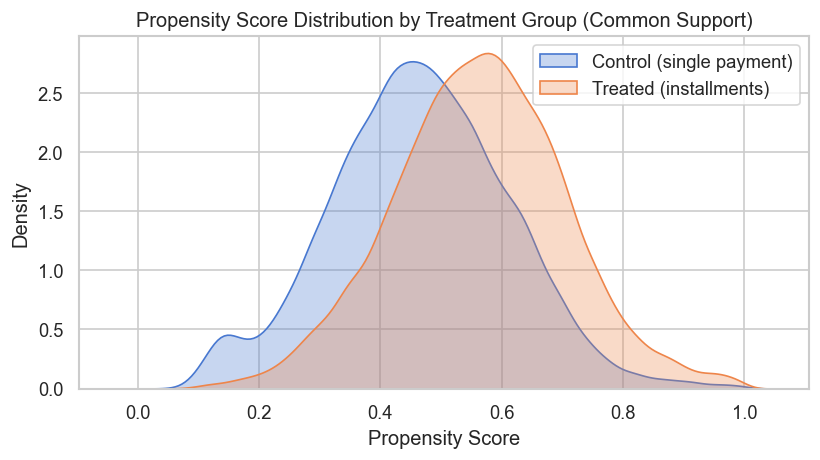

In [401]:
fig, ax = plt.subplots(figsize=(7, 4))

for label, group in df_model.groupby(TREATMENT):
    sns.kdeplot(group["propensity_score"], ax=ax, fill=True, alpha=0.3,
                label="Treated (installments)" if label == 1 else "Control (single payment)")

ax.set_xlabel("Propensity Score")
ax.set_title("Propensity Score Distribution by Treatment Group (Common Support)")
ax.legend()
plt.tight_layout()
plt.savefig("propensity_overlap.png")

In [402]:
ps_treated = df_model[df_model[TREATMENT] == 1]["propensity_score"]
ps_control = df_model[df_model[TREATMENT] == 0]["propensity_score"]

# Common support = the intersection of both score ranges
# overlap_min: the highest minimum (below this, only controls exist)
# overlap_max: the lowest maximum (above this, only treated units exist)
overlap_min = max(ps_treated.min(), ps_control.min())
overlap_max = min(ps_treated.max(), ps_control.max())

print(f"Common support region: [{overlap_min:.3f}, {overlap_max:.3f}]")
print(f"Treated units outside common support: {(ps_treated > overlap_max).sum()} of {len(ps_treated)}")
print(f"\nThese units will be excluded from matching — no comparable control exists for them.")

Common support region: [0.032, 1.000]
Treated units outside common support: 0 of 49195

These units will be excluded from matching — no comparable control exists for them.


In [403]:
# Caliper = 0.2 × SD of the propensity score (Austin, 2011)
# This is computed on the full sample before trimming to common support
caliper = 0.2 * df_model["propensity_score"].std()

print(f"Propensity score SD : {df_model['propensity_score'].std():.4f}")
print(f"Caliper (0.2 × SD) : {caliper:.4f}")
print(f"\nScore range         : [{df_model['propensity_score'].min():.3f}, {df_model['propensity_score'].max():.3f}]")
print(f"Caliper as % of range: {caliper / (df_model['propensity_score'].max() - df_model['propensity_score'].min()) * 100:.1f}%")
print(f"\nA caliper of {caliper:.4f} means two units must be within ~{caliper:.3f} propensity score")
print(f"points of each other to be considered a valid match.")

Propensity score SD : 0.1534
Caliper (0.2 × SD) : 0.0307

Score range         : [0.007, 1.000]
Caliper as % of range: 3.1%

A caliper of 0.0307 means two units must be within ~0.031 propensity score
points of each other to be considered a valid match.


In [404]:
# Separate the two pools we are matching from.
# .copy() ensures modifications (like removing matched controls) don't affect df.
treated = df_model[df_model[TREATMENT] == 1].copy()  # the 403 quitters — each needs one match
control = df_model[df_model[TREATMENT] == 0].copy()  # the 1163 non-quitters — the matching pool

print(f"Treated pool: {len(treated)}")
print(f"Control pool: {len(control)}")
print(f"\nFor every treated we will find their nearest neighbour in the control pool.")
print(f"If the distance exceeds the caliper ({caliper:.4f}), the quitter is dropped.")

Treated pool: 49195
Control pool: 46461

For every treated we will find their nearest neighbour in the control pool.
If the distance exceeds the caliper (0.0307), the quitter is dropped.


In [405]:
nn = NearestNeighbors(n_neighbors=1, metric="euclidean")
nn.fit(control[["propensity_score"]])

distances, indices = nn.kneighbors(treated[["propensity_score"]])

print(distances[:5])
print(indices[:5])

[[1.76259951e-06]
 [3.45498258e-07]
 [8.90744643e-06]
 [8.15984472e-07]
 [8.99290716e-06]]
[[ 6939]
 [36604]
 [ 1595]
 [43850]
 [37507]]


In [406]:
import random
from sortedcontainers import SortedKeyList

random.seed(42)
treated_shuffled = treated.sample(frac=1, random_state=42)

# Sorted pool of (propensity_score, control_row_index), sorted by score.
# Matching on a single scalar is a 1-D nearest-neighbor problem: the nearest
# available point to any target is always its predecessor or successor in
# sorted order, so a sorted structure with O(log n) removal is all we need
# — no need to rebuild a KD-tree from scratch on every iteration.
available_scores = SortedKeyList(
    ((row.propensity_score, idx) for idx, row in control.iterrows()),
    key=lambda pair: pair[0]
)

matched_treated = []
matched_control_idx = []
unmatched = 0

for _, t_row in treated_shuffled.iterrows():
    if not available_scores:
        unmatched += 1
        continue

    target = t_row["propensity_score"]
    pos = available_scores.bisect_key_left(target)

    candidates = []
    if pos < len(available_scores):
        candidates.append(available_scores[pos])
    if pos > 0:
        candidates.append(available_scores[pos - 1])

    best_score, best_idx = min(candidates, key=lambda pair: abs(pair[0] - target))

    if abs(best_score - target) > caliper:
        unmatched += 1
        continue

    available_scores.remove((best_score, best_idx))
    matched_treated.append(t_row)
    matched_control_idx.append(best_idx)

matched_control = control.loc[matched_control_idx]

print(f"Matched pairs             : {len(matched_treated)}")
print(f"Dropped (caliper/no match): {unmatched}")
print(f"Unique controls used      : {len(set(matched_control_idx))}")
print(f"Duplicates                : {len(matched_control_idx) - len(set(matched_control_idx))}")

Matched pairs             : 34955
Dropped (caliper/no match): 14240
Unique controls used      : 34955
Duplicates                : 0


In [407]:
control_ids = matched_control.index.tolist()
print(f"Total matches       : {len(control_ids)}")
print(f"Unique controls used: {len(set(control_ids))}")
print(f"Duplicates          : {len(control_ids) - len(set(control_ids))}")

Total matches       : 34955
Unique controls used: 34955
Duplicates          : 0


In [408]:
matched_treated_df = pd.DataFrame(matched_treated).reset_index(drop=True)
matched_treated_df["pair_id"] = range(len(matched_treated_df))

matched_control_df = matched_control.reset_index(drop=True)
matched_control_df["pair_id"] = range(len(matched_control_df))

matched_df = pd.concat([matched_treated_df, matched_control_df], ignore_index=True)

print(f"Matched sample shape: {matched_df.shape}")
matched_df.groupby(TREATMENT).size()

Matched sample shape: (69910, 26)


has_payment_installments
0    34955
1    34955
dtype: int64

In [409]:
balance_post = smd(matched_df, COVARIATES, TREATMENT)

balance_post

,mean_treated,mean_control,smd
covariate,,,
order_value,152.473457,139.837292,0.067651
pct_of_price,0.207143,0.205492,0.014208
n_items,1.145501,1.139293,0.011617
days_to_estimated,23.243484,23.316607,-0.008479
days_to_carrier,2.738464,2.754885,-0.004617
days_to_customer,11.941782,11.982549,-0.004458


In [410]:
outcome_by_pair = matched_df.pivot(index="pair_id", columns=TREATMENT, values=OUTCOME)
treated_outcome = outcome_by_pair[1]
control_outcome = outcome_by_pair[0]

paired_diff = treated_outcome - control_outcome
diff_values = paired_diff.values
mean_diff = diff_values.mean()



Mean review_score (treated) : 4.1417
Mean review_score (control) : 4.1868
Mean paired difference      : -0.0451
Bootstrap 95% CI (2000 resamples): [-0.0633, -0.0267]


In [413]:
# Bootstrap the paired difference: resample pairs (with replacement) rather
# than assume a t-distribution, which better suits a bounded 1-5 Likert outcome.
n_boot = 2000
rng = np.random.default_rng(42)
n = len(diff_values)
boot_means = np.array([rng.choice(diff_values, size=n, replace=True).mean() for _ in range(n_boot)])
ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])

print(f"Mean review_score (treated) : {treated_outcome.mean():.4f}")
print(f"Mean review_score (control) : {control_outcome.mean():.4f}")
print(f"Mean paired difference      : {mean_diff:.4f}")
print(f"Bootstrap 95% CI ({n_boot} resamples): [{ci_low:.4f}, {ci_high:.4f}]")

Mean review_score (treated) : 4.1417
Mean review_score (control) : 4.1868
Mean paired difference      : -0.0451
Bootstrap 95% CI (2000 resamples): [-0.0633, -0.0267]


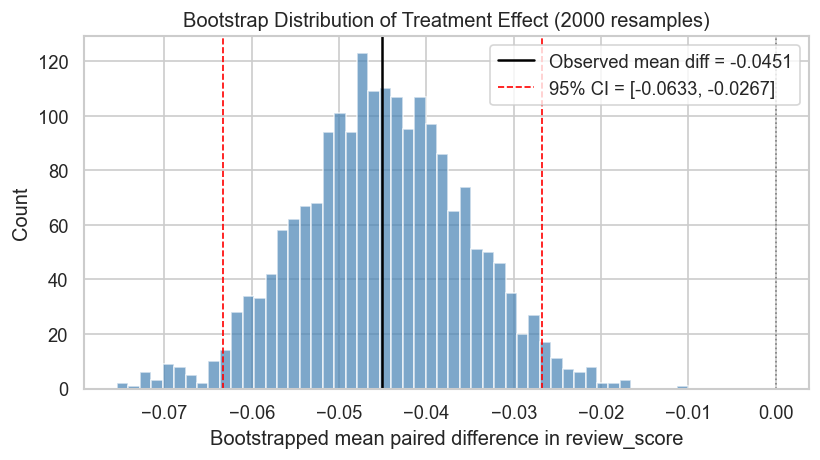

In [412]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(boot_means, bins=50, color="steelblue", alpha=0.7, edgecolor="white")
ax.axvline(mean_diff, color="black", linewidth=1.5, label=f"Observed mean diff = {mean_diff:.4f}")
ax.axvline(ci_low, color="red", linestyle="--", linewidth=1, label=f"95% CI = [{ci_low:.4f}, {ci_high:.4f}]")
ax.axvline(ci_high, color="red", linestyle="--", linewidth=1)
ax.axvline(0, color="gray", linewidth=1, linestyle=":")

ax.set_xlabel("Bootstrapped mean paired difference in review_score")
ax.set_ylabel("Count")
ax.set_title(f"Bootstrap Distribution of Treatment Effect ({n_boot} resamples)")
ax.legend()
plt.tight_layout()
plt.savefig("bootstrap_distribution.png")